In [1]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import glob
import cv2

# *1- Import Data*

In [2]:
#Get the data Paths
path_apple_test = glob.glob('/kaggle/input/datasets/badiawissam/dataset-images/Dataset/apple/test/*.png')
path_apple_train = glob.glob('/kaggle/input/datasets/badiawissam/dataset-images/Dataset/apple/train/*.png')
path_lemon_test = glob.glob('/kaggle/input/datasets/badiawissam/dataset-images/Dataset/lemon/test/*.png')
path_lemon_train = glob.glob('/kaggle/input/datasets/badiawissam/dataset-images/Dataset/lemon/train/*.png')

In [3]:
#upload the train images
X_train = []
y_train = []

#Append the images to the lists
for file in path_apple_train:
    img = cv2.imread(file)
    
    X_train.append(cv2.resize(img,(64,64)))
    #X_train.append(img)
    y_train.append(0)
    
for file in path_lemon_train :
    img = cv2.imread(file)
    X_train.append(cv2.resize(img,(64,64)))
    #X_train.append(img)
    y_train.append(1)
    
#Convert to np array
X_train  = np.array(X_train)
y_train= np.array(y_train)

In [4]:
#upload the train images
X_test = []
y_test = []

#Append the images to the lists
for file in path_apple_test:
    img = cv2.imread(file)
    X_test.append(cv2.resize(img,(64,64)))
    #X_test.append(img)
    y_test.append(0)
    
for file in path_lemon_test :
    img = cv2.imread(file)
    X_test.append(cv2.resize(img,(64,64)))
    #X_test.append(img)
    y_test.append(1)

#Convert to np array

X_test  = np.array(X_test)
y_test = np.array(y_test)

In [5]:
print(f"the train sent contains {len(X_train)}, and the test contains {len(X_test)} images")

the train sent contains 200, and the test contains 100 images


In [6]:
print("the size of each image is ", X_train[0].shape)

the size of each image is  (64, 64, 3)


# *2-Pre-Processing step*

In [7]:
#Convert images to the gray scale
X_train_gray = []
X_test_gray = []

for i in X_train:
    X_train_gray.append(cv2.cvtColor(i, cv2.COLOR_BGR2GRAY))
X_train_gray = np.array(X_train_gray)

for i in X_test:
    X_test_gray.append(cv2.cvtColor(i, cv2.COLOR_BGR2GRAY))
X_test_gray = np.array(X_test_gray)


In [8]:
#Reshape the image to 1d array and normalize the pixels using Min-Max normalization
X_train_arr = []
X_test_arr = []

for i in X_train_gray:
    X_train_arr.append(i.reshape(-1))
X_train_arr = (np.array(X_train_arr)).T/255
#X_train_arr = (X_train_arr/255)

for i in X_test_gray:
    X_test_arr.append(i.reshape(-1))
X_test_arr = (np.array(X_test_arr)).T/255
#X_test_arr = (X_test_arr/255)



# *3-Model creation*

*Define activation functions and their derivatives*

In [13]:
def RELU(x):
    return np.maximum(0,x)

def Sigmoid(x):
    return 1/(1+np.exp(-x))
    #return np.exp(x)/(np.exp(x)+1)

def d_RELU(x):
    #if (x>0).any(): return 1
    #else: return 0
        x[x<=0] = 0
        x[x>0] = 1
        return x
    
def d_Sigmoid(x):
    return Sigmoid(x)*(1-Sigmoid(x))


For the model, it will be with one hidden layer


In [14]:
#num of weights = neurons of 1st layer * neurons of newt layer.
#number of b = neurons of the next layer.

#Weight initialization function
def initial_weight (n,z=1):
    if(z==0):
        Ws1 = np.zeros((200,n)) 
        bs1 = np.zeros((200,1))
        Ws2 = np.zeros((1,200)) 
        bs2 = np.zeros(1)
    else:
        Ws1 = np.random.randn(200,n) 
        bs1 = np.random.randn(200,1)
        Ws2 = np.random.randn(1,200) 
        bs2 = np.random.randn(1)
    
    return Ws1,Ws2,bs1,bs2

In [15]:
def forward_pass(W1,W2,b1,b2,X,act):
    if act == "Relu":
        Z1 = W1 @ X + b1
        A1 = RELU(Z1)
        Z2 = W2 @ A1 + b2
        A2 = RELU(Z2)
        return Z1, A1, Z2, A2
    
    elif act == "Sigmoid":
        Z1 = W1 @ X + b1
        A1 = Sigmoid(Z1)
        Z2 = W2 @ A1 + b2
        A2 = Sigmoid(Z2)
        return Z1, A1, Z2, A2
    
    else:
        raise ValueError(f"Invalid activation function '{act}'. Choose either 'Relu' or 'Sigmoid'.")
        
    

**Batch gradient descent**

In [16]:

def bach_gradient_descent(X,y_true,epochs,act,z=1,lr=0.01):
    #check the activation function
    if not (act == 'Relu' or act == 'Sigmoid'):
        raise ValueError(f"Invalid activation function '{act}'. Choose either 'Relu' or 'Sigmoid'.")    
    
    number_of_feature = X.shape[0]
    total_samples = X.shape[1]
    W1,W2,b1,b2 = initial_weight(number_of_feature,z)
    
    loss_list = []
    epochs_list = []
    
    for i in range (epochs):
        
        #forward pass and predict the output
        z1,a1,z2,y_pred = forward_pass(W1,W2,b1,b2,X,act)
        
        #calculate the MSE
        mse = (1/total_samples)*np.sum(((y_true-y_pred)**2))
        
        #Calculate the gradients
        ##output-hidden
        dmse_dpred = (-2/total_samples)*(y_true-y_pred)
        
        if(act=='Sigmoid'):
            dpred_dz2 = d_Sigmoid(z2)
        else:
            dpred_dz2 = d_RELU(z2)
            
        dz2_dw2 = a1
        dz2_db2 = np.ones(1)

        dmse_dw2 = ((dmse_dpred* dpred_dz2) @dz2_dw2.T)
        dmse_db2 = ((dmse_dpred@ dpred_dz2.T) @dz2_db2)
        
        #hidden-input
        dz2_da1 = W2*(np.transpose(a1))
        
        if(act=='Sigmoid'):
            da1_dz1 = d_Sigmoid(z1)
        else:
            da1_dz1 = d_RELU(z1)
            
        '''up_x = []
        for i in range(total_samples):
            up_x.append((X[:,i]*np.ones((200,1))))
        dz1_dw1 = np.array(up_x)
        #(np.array(up_x)).shape'''
        
        dz1_dw1 = X
        dz1_db1 = np.ones((1,200))
        
        dmse_dw1 = ((dmse_dpred.T@dpred_dz2@dz2_da1).T * da1_dz1@dz1_dw1.T)
        dmse_db1 = ((dmse_dpred.T@dpred_dz2@dz2_da1).T @ da1_dz1.T@dz1_db1.T)
        
        #Upload the weights and biases
        W1 -= lr*dmse_dw1
        W2 -= lr*dmse_dw2
        b1 -= lr*dmse_db1
        b2 -= lr*dmse_db2
        
        #append the coast and the epochs
        print(f'{i+1}/{epochs}, The loss = {mse}\n' )
        
        loss_list.append(mse)
        epochs_list.append(i)
        
        
    return W1,W2,b1,b2,np.array(loss_list),np.array(epochs_list)
        

In [17]:
#Train the model (choose z=0 for initializing with 0,  otherwise the training is normalized with a normal distribution as default)
W1,W2,b1,b2,losses,epochs = bach_gradient_descent(X_train_arr,y_train,200,act='Sigmoid')


1/200, The loss = 0.4880693726822451

2/200, The loss = 0.48443255571562943

3/200, The loss = 0.4779809185602226

4/200, The loss = 0.463796812069533

5/200, The loss = 0.4382700975998121

6/200, The loss = 0.40781424221532553

7/200, The loss = 0.3658471376495134

8/200, The loss = 0.2746442203065962

9/200, The loss = 0.24853922009043877

10/200, The loss = 0.2161265459583668

11/200, The loss = 0.2015957541965642

12/200, The loss = 0.1938052021930054

13/200, The loss = 0.18306607144321596

14/200, The loss = 0.17845090587889365

15/200, The loss = 0.16765490510682265

16/200, The loss = 0.16153430052168294

17/200, The loss = 0.15718515222716872

18/200, The loss = 0.15361831696974826

19/200, The loss = 0.1480662682854398

20/200, The loss = 0.14573216231788

21/200, The loss = 0.1413613820047039

22/200, The loss = 0.1411261192658172

23/200, The loss = 0.13452383448878139

24/200, The loss = 0.13436436075475336

25/200, The loss = 0.12861639048898243

26/200, The loss = 0.1295

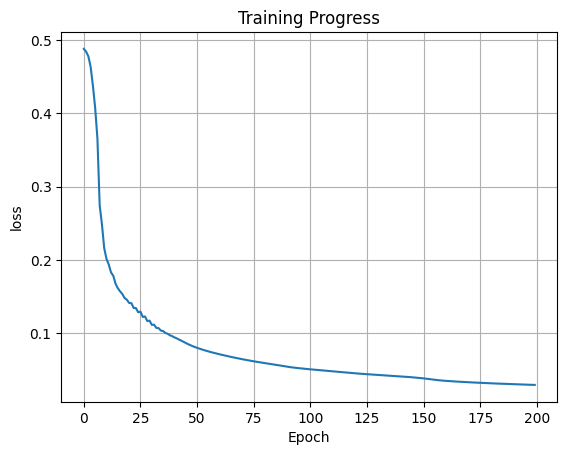

In [18]:
#epochs = 700
#plot the training loss
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.plot(epochs, losses)
plt.title("Training Progress")  
plt.grid(True)  
plt.show()  
#plt.plot(epochs,np.flip(coasts,0))

In [19]:
#use the forward function to evaluate the model
z1,a1,z2,y_pred=forward_pass(W1,W2,b1,b2,X_test_arr,act='Sigmoid')
y_pred = [1 if y>= 0.5 else 0 for y in y_pred[0]]
print("Confusion Matrix of the model : \n",confusion_matrix(y_test, y_pred))

Confusion Matrix of the model : 
 [[29 21]
 [ 2 48]]


In [20]:
#train the model using Relu as activation
W1,W2,b1,b2,losses,epochs = bach_gradient_descent(X_train_arr,y_train,200,act='Relu')

1/200, The loss = 120.85005902290037

2/200, The loss = 0.5

3/200, The loss = 0.5

4/200, The loss = 0.5

5/200, The loss = 0.5

6/200, The loss = 0.5

7/200, The loss = 0.5

8/200, The loss = 0.5

9/200, The loss = 0.5

10/200, The loss = 0.5

11/200, The loss = 0.5

12/200, The loss = 0.5

13/200, The loss = 0.5

14/200, The loss = 0.5

15/200, The loss = 0.5

16/200, The loss = 0.5

17/200, The loss = 0.5

18/200, The loss = 0.5

19/200, The loss = 0.5

20/200, The loss = 0.5

21/200, The loss = 0.5

22/200, The loss = 0.5

23/200, The loss = 0.5

24/200, The loss = 0.5

25/200, The loss = 0.5

26/200, The loss = 0.5

27/200, The loss = 0.5

28/200, The loss = 0.5

29/200, The loss = 0.5

30/200, The loss = 0.5

31/200, The loss = 0.5

32/200, The loss = 0.5

33/200, The loss = 0.5

34/200, The loss = 0.5

35/200, The loss = 0.5

36/200, The loss = 0.5

37/200, The loss = 0.5

38/200, The loss = 0.5

39/200, The loss = 0.5

40/200, The loss = 0.5

41/200, The loss = 0.5

42/200, Th

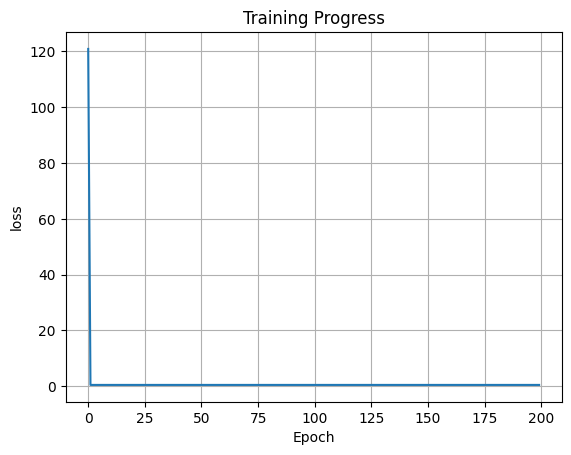

In [21]:
#plot the training loss
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.plot(epochs, losses)
plt.title("Training Progress")  
plt.grid(True)  
plt.show() 

In [22]:
z1,a1,z2,y_pred=forward_pass(W1,W2,b1,b2,X_test_arr,act='Relu')
y_pred = [1 if y>= 0.5 else 0 for y in y_pred[0]]
print("Confusion Matrix of the model : \n",confusion_matrix(y_test, y_pred))

Confusion Matrix of the model : 
 [[50  0]
 [50  0]]


**Mini-Batch gradient descent**

In [23]:
#create mini bacthes for the data
def create_mini_batches(data, y, batch_size=50):
    mini_batches_x = []
    mini_batches_y = []
    n_minibatches = data.shape[1] // batch_size
    i = 0
    for i in range (n_minibatches+1):
        mini_batch_x = data[:,i*batch_size:(i+1)*batch_size]
        mini_batch_y = y[i*batch_size:(i+1)*batch_size]
        mini_batches_x.append(mini_batch_x)
        mini_batches_y.append(mini_batch_y)
        
        
    if data.shape[1] % batch_size != 0:
        mini_batch_x = data[i * batch_size:data.shape[1]]
        mini_batch_y = y[i * batch_size:y.shape[1]]
        X_mini = mini_batch_x[:, :-1]
        Y_mini = mini_batch_y[:, -1].reshape((-1, 1))
        mini_batches.append((X_mini, Y_mini))
    return mini_batches_x[0:-1],mini_batches_y[0:-1]

In [24]:
mini_x,mini_y = create_mini_batches(X_train_arr, y_train)
mini_x[0].shape

(4096, 50)

In [25]:
def minibach_gradiant_descent(X,y_true,epochs,act,z=1,lr=0.01):
    
    number_of_feature = X.shape[0]
    total_samples = X.shape[1]
    
    mini_x,mini_y = create_mini_batches(X, y_true)
    loss_list = []
    epochs_list = []
    W1,W2,b1,b2 = initial_weight(number_of_feature,z)
    
    for i in range (epochs):
        
        a = []
        for j in range(len(mini_x)):
            n=mini_x[j].shape[1]
            
            z1,a1,z2,y_pred = forward_pass(W1,W2,b1,b2,mini_x[j],act)
            
            a.append((mini_y[j]-y_pred)**2)
            

            dmse_dpred = (-2/n)*(mini_y[j]-y_pred)
            if(act=='Sigmoid'):
                dpred_dz2 = d_Sigmoid(z2)
            else:
                dpred_dz2 = d_RELU(z2)
            dz2_dw2 = a1
            dz2_db2 = np.ones(1)
            
            dmse_dw2 = ((dmse_dpred* dpred_dz2) @dz2_dw2.T)
            dmse_db2 = ((dmse_dpred@ dpred_dz2.T) @dz2_db2)


            dz2_da1 =W2*(np.transpose(a1))
            if(act=='Sigmoid'):
                da1_dz1 = d_Sigmoid(z1)
            else:
                da1_dz1 = d_RELU(z1)
            
            dz1_dw1 = mini_x[j]
            dz1_db1 = np.ones((1,200))
            
            
            dmse_dw1 = ((dmse_dpred.T@dpred_dz2@dz2_da1).T * da1_dz1@dz1_dw1.T)
            dmse_db1 = ((dmse_dpred.T@dpred_dz2@dz2_da1).T @ da1_dz1.T@dz1_db1.T)


            W1 -= lr*dmse_dw1
            W2 -= lr*dmse_dw2
            b1 -= lr*dmse_db1
            b2 -= lr*dz2_db2
        
            
        print(f'\n{i+1}/{epochs}, the loss is {(1/total_samples)*np.sum(a)}')
        loss_list.append((1/total_samples)*np.sum(a))
        epochs_list.append(i)
        
    return W1,W2,b1,b2,np.array(loss_list),np.array(epochs_list)
        

In [26]:
#train the model using sigmoid
w1,w2,b1,b2,losses,epochs = minibach_gradiant_descent(X_train_arr,y_train,200,act='Sigmoid')



1/200, the loss is 0.45115003365279066

2/200, the loss is 0.42359224352209224

3/200, the loss is 0.34515104701757593

4/200, the loss is 0.3158589180819727

5/200, the loss is 0.2675917343512846

6/200, the loss is 0.19730864969415676

7/200, the loss is 0.17359554233834001

8/200, the loss is 0.15817229597398352

9/200, the loss is 0.1496907067808658

10/200, the loss is 0.14260657981454272

11/200, the loss is 0.1368036879238874

12/200, the loss is 0.1315463301472494

13/200, the loss is 0.1269452848784965

14/200, the loss is 0.12303653320015126

15/200, the loss is 0.11966729033094754

16/200, the loss is 0.11661880288869796

17/200, the loss is 0.11374170512573521

18/200, the loss is 0.11099362935122092

19/200, the loss is 0.10841394259661036

20/200, the loss is 0.10595537203844374

21/200, the loss is 0.10355415315008461

22/200, the loss is 0.1011931349308295

23/200, the loss is 0.09888924605576264

24/200, the loss is 0.09668301019713242

25/200, the loss is 0.094615631

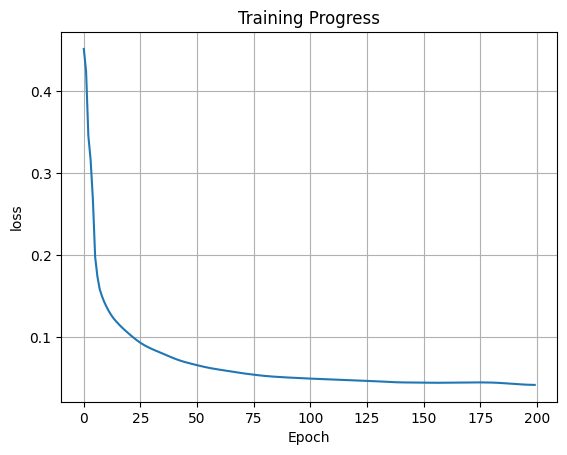

In [27]:
#plot the training loss
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.plot(epochs, losses)
plt.title("Training Progress")  
plt.grid(True)  
plt.show() 

In [28]:
#Evaluate the model for the test
z1,a1,z2,y_pred=forward_pass(W1,W2,b1,b2,X_test_arr,act='Sigmoid')
#y_pred[0]
y_pred = [1 if y>= 0.5 else 0 for y in y_pred[0]]
print("Confusion Matrix of the model : \n",confusion_matrix(y_test, y_pred))

Confusion Matrix of the model : 
 [[50  0]
 [50  0]]


/tmp/ipykernel_55/2714802600.py:5: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))


In [29]:
#train the model using the ReLU activation function
w1,w2,b1,b2,losses,epochs = minibach_gradiant_descent(X_train_arr,y_train,200,act='Relu')



1/200, the loss is 19.304221402213877

2/200, the loss is 0.5

3/200, the loss is 0.5

4/200, the loss is 0.5

5/200, the loss is 0.5

6/200, the loss is 0.5

7/200, the loss is 0.5

8/200, the loss is 0.5

9/200, the loss is 0.5

10/200, the loss is 0.5

11/200, the loss is 0.5

12/200, the loss is 0.5

13/200, the loss is 0.5

14/200, the loss is 0.5

15/200, the loss is 0.5

16/200, the loss is 0.5

17/200, the loss is 0.5

18/200, the loss is 0.5

19/200, the loss is 0.5

20/200, the loss is 0.5

21/200, the loss is 0.5

22/200, the loss is 0.5

23/200, the loss is 0.5

24/200, the loss is 0.5

25/200, the loss is 0.5

26/200, the loss is 0.5

27/200, the loss is 0.5

28/200, the loss is 0.5

29/200, the loss is 0.5

30/200, the loss is 0.5

31/200, the loss is 0.5

32/200, the loss is 0.5

33/200, the loss is 0.5

34/200, the loss is 0.5

35/200, the loss is 0.5

36/200, the loss is 0.5

37/200, the loss is 0.5

38/200, the loss is 0.5

39/200, the loss is 0.5

40/200, the loss i

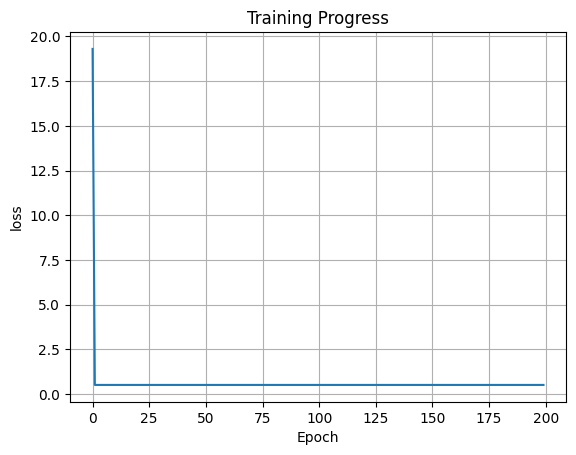

In [30]:
#plot the training loss
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.plot(epochs, losses)
plt.title("Training Progress")  
plt.grid(True)  
plt.show() 

In [31]:
#Evaluate the trained model trained with the ReLU activation function
z1,a1,z2,y_pred=forward_pass(W1,W2,b1,b2,X_test_arr,act='Relu')
y_pred = [0 if y<=0.5 else 1 for y in y_pred[0]]
print("Confusion Matrix of the model : \n",confusion_matrix(y_test, y_pred))

Confusion Matrix of the model : 
 [[50  0]
 [50  0]]


**Stocastic grediant descent**

In [34]:
def SGD(x,y_true,epochs,act,z=1,lr=0.01):
    
    number_of_feature,total_samples = x.shape
    
    W1,W2,b1,b2 = initial_weight(number_of_feature,z)
    
    loss_list = []
    epoch_list = []
    mse = []
    for i in range(epochs):

        random_index = np.random.randint(0,total_samples -1)
        sample_x = np.expand_dims(x[:,random_index], axis=-1)
        sample_y = y_true[random_index]
        
        #Forward pass
        z1,a1,z2,y_pred = forward_pass(W1,W2,b1,b2,sample_x,act)
        ny = forward_pass(W1,W2,b1,b2,x,act)[3]
        mse = (y_true-ny)**2
            
        # Calculate MSE
        
        #mse.append((sample_y - y_pred[0,0])**2)
        
        #Backward pass
        
        dmse_dpred = np.array([[(-2)*(sample_y - y_pred[0][0])]])
        if (act == 'Sigmoid'):
            dpred_dz2 = d_Sigmoid(z2)
        else:
            dpred_dz2 = d_RELU(z2)
            
        dz2_dw2 = a1
        dz2_db2 = np.ones(1)
        
        dmse_dw2 = (dz2_dw2 @ dpred_dz2 @ dmse_dpred).T
        dmse_db2 = (dz2_db2 @ dpred_dz2 @ dmse_dpred).T
        
            
        dz2_da1 =W2*(np.transpose(a1))
        if (act == 'Sigmoid' ):
            da1_dz1 = d_Sigmoid(z1)
        else:
            da1_dz1 = d_RELU(z1)

        dz1_dw1 = sample_x
        dz1_db1 = np.array([np.ones(200)])
         
        
        dmse_dw1 = (((dmse_dpred@dpred_dz2@dz2_da1).T*da1_dz1)@dz1_dw1.T)
        dmse_db1 = ((dmse_dpred@dpred_dz2@dz2_da1).T* da1_dz1*dz1_db1.T)
        
        
        W1 = W1 - lr* dmse_dw1
        W2 = W2 - lr* dmse_dw2
        b1 = b1 - lr* dmse_db1
        b2 = b2 - lr* dmse_db2
        
        #print
        print(f'\n{i+1}/{epochs}, the loss {(1/total_samples)*np.sum(mse)}')
        loss_list.append((1/total_samples)*np.sum(mse))
        epoch_list.append(i)
        
    return W1, W2, b1 ,b2, np.array(loss_list), np.array(epoch_list)


In [35]:
#Train the model using sigmoid
w1,w2,b1,b2,losses,epochs = SGD(X_train_arr,y_train,200,act='Sigmoid')



1/200, the loss 0.3959816057021751

2/200, the loss 0.3959816049910264

3/200, the loss 0.39598123510045635

4/200, the loss 0.37312803968729163

5/200, the loss 0.3731280378707544

6/200, the loss 0.37407260057284514

7/200, the loss 0.37407260159601796

8/200, the loss 0.37544143828588233

9/200, the loss 0.3636333242331245

10/200, the loss 0.3636229241781627

11/200, the loss 0.3636229269058211

12/200, the loss 0.3636232423280597

13/200, the loss 0.36362326162860953

14/200, the loss 0.3632059972990417

15/200, the loss 0.3631431208228409

16/200, the loss 0.3631430003474195

17/200, the loss 0.36314287986986615

18/200, the loss 0.3631428798974071

19/200, the loss 0.3631464160460764

20/200, the loss 0.36027052215100697

21/200, the loss 0.36027058971225323

22/200, the loss 0.3602705897157262

23/200, the loss 0.35317521154794973

24/200, the loss 0.3375547965096821

25/200, the loss 0.34309733656426034

26/200, the loss 0.3388511842297619

27/200, the loss 0.3388511842341989

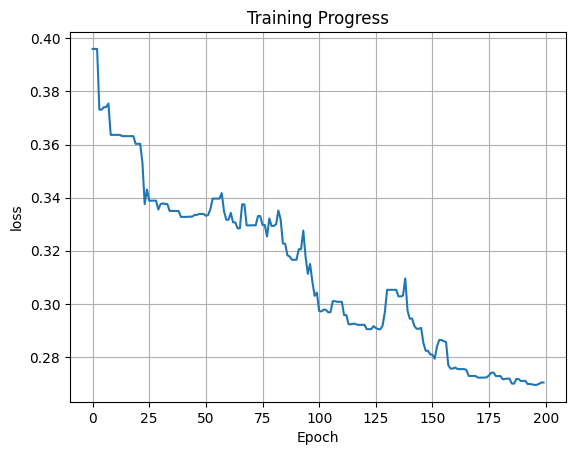

In [36]:
#plot the training loss
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.plot(epochs, losses)
plt.title("Training Progress")  
plt.grid(True)  
plt.show() 

In [37]:
z1,a1,z2,y_pred=forward_pass(W1,W2,b1,b2,X_test_arr,act='Sigmoid')
y_pred = [0 if y<=0.5 else 1 for y in y_pred[0]]
print("Confusion Matrix of the model : \n",confusion_matrix(y_test, y_pred))

Confusion Matrix of the model : 
 [[50  0]
 [50  0]]


/tmp/ipykernel_55/2714802600.py:5: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))


In [38]:
#train the model with the ReLU activation fucntion
w1,w2,b1,b2,losses,epochs = SGD(X_train_arr,y_train,200,act='Relu')



1/200, the loss 6848.123699612552

2/200, the loss 6848.123699612552

3/200, the loss 0.5

4/200, the loss 0.5

5/200, the loss 0.5

6/200, the loss 0.5

7/200, the loss 0.5

8/200, the loss 0.5

9/200, the loss 0.5

10/200, the loss 0.5

11/200, the loss 0.5

12/200, the loss 0.5

13/200, the loss 0.5

14/200, the loss 0.5

15/200, the loss 0.5

16/200, the loss 0.5

17/200, the loss 0.5

18/200, the loss 0.5

19/200, the loss 0.5

20/200, the loss 0.5

21/200, the loss 0.5

22/200, the loss 0.5

23/200, the loss 0.5

24/200, the loss 0.5

25/200, the loss 0.5

26/200, the loss 0.5

27/200, the loss 0.5

28/200, the loss 0.5

29/200, the loss 0.5

30/200, the loss 0.5

31/200, the loss 0.5

32/200, the loss 0.5

33/200, the loss 0.5

34/200, the loss 0.5

35/200, the loss 0.5

36/200, the loss 0.5

37/200, the loss 0.5

38/200, the loss 0.5

39/200, the loss 0.5

40/200, the loss 0.5

41/200, the loss 0.5

42/200, the loss 0.5

43/200, the loss 0.5

44/200, the loss 0.5

45/200, the 

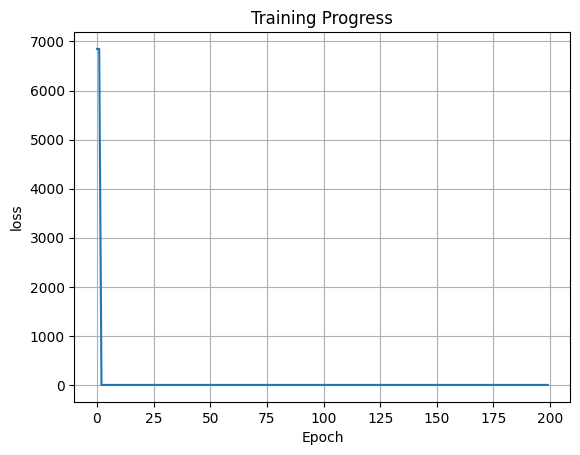

In [39]:
#plot the training loss
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.plot(epochs, losses)
plt.title("Training Progress")  
plt.grid(True)  
plt.show() 

In [40]:
#Evaluate the model that was trained with relu
z1,a1,z2,y_pred=forward_pass(W1,W2,b1,b2,X_test_arr,act='Relu')
y_pred = [0 if y<=0.5 else 1 for y in y_pred[0]]
print("Confusion Matrix of the model : \n",confusion_matrix(y_test, y_pred))

Confusion Matrix of the model : 
 [[50  0]
 [50  0]]


In [ ]:
#from tensorflow import keras
#import tensorflow as tf
#from tensorflow.keras.models import Sequential, load_model
#from tensorflow.keras.layers import Dense,Dropout
#from sklearn.metrics import accuracy_score

In [ ]:
#tf.keras.backend.clear_session()
#model = Sequential()

#model.add(Dense(units=200, activation='sigmoid', input_dim=4096))

#model.add(Dense(units=1, activation='sigmoid'))

In [ ]:
#model.summary()

In [ ]:
#model.compile(optimizer="SGD",
#              loss='mse',
#              metrics = ['accuracy'])

In [ ]:
#model.fit(X_train_arr.T, y_train,batch_size=200, epochs=200)

In [ ]:
#y_hat = model.predict(X_test_arr.T)

In [ ]:
#model.evaluate(X_test_arr.T, y_test)